# Practico 2 - Redes Bayesianas y Estimación de distribuciones continuas.

El objetivo de esta notebook es implementar las redes bayesianas sobre el dataset de Tennis y continuar explorando formas de estimar distribuciones pero esta vez sobre datos continuos. 

## Parte 1: Redes Bayesianas

## Imports

In [1]:
import pgmpy

print(pgmpy.__version__)

1.1.2


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

/Users/josefina.lin/Documents/GitHub/ORT-AI/ia-generativa/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/josefina.lin/Documents/GitHub/ORT-AI/ia-generativa/lib/python3.11/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


### Paso 1: Cargar los Datos y Construir el Modelo

In [3]:
# Cargar los datos
data = pd.read_csv('./tennis.csv')
data.head()

,Day,Outlook,Temp,Humidity,Wind,Tennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


Definimos variables aleatorias que vamos a usar. Por simplicidad en la visualización solo usaremos 3, pero puede usar todas las que quiera.

In [4]:
outlook = 'Outlook'
temp = 'Temp'
wind = 'Wind'
tennis = 'Tennis'
humidity = 'Humidity'

data = data[[outlook, temp, tennis]]

Tenemos que definir las relaciones condicionales que hay entre estas variables, para eso vamos a definir las siguientes relaciones: 

- Tennis depende de Outlook
- Tennis depende de Temp

In [5]:
relations = [(outlook, tennis), (temp, tennis)]

Teniendo las relaciones vamos a crear nuestro modelo!

In [6]:
model = DiscreteBayesianNetwork(relations)

Ahora que tenemos el modelo vamos a ajustarlo para que capture las probabilidades condicionales en las observaciones.

In [7]:
# Aprender los CPDs desde los datos
model.fit(data, estimator=DiscreteMLE())

Verificamos si el modelo es valido.

In [8]:
model.check_model()

True

### Paso 2: Visualización del Grafo y CPDs

In [9]:
def visualize_graph(model):
    G = nx.DiGraph()
    G.add_edges_from(model.edges())
    plt.figure(figsize=(7, 5))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=10000, node_color="skyblue", font_size=14, font_weight="bold", arrowsize=30)
    plt.title("Red Bayesiana del Dataset de Tenis")
    plt.show()

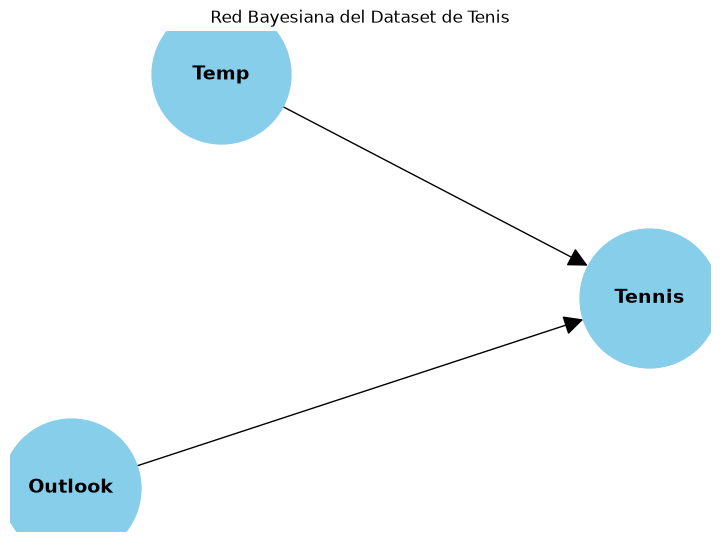

In [10]:
visualize_graph(model)

In [11]:
for cpd in model.get_cpds():
    print(f"CPD de {cpd.variable}:")
    print(cpd)

CPD de Outlook:
+-------------------+----------+
| Outlook(Overcast) | 0.285714 |
+-------------------+----------+
| Outlook(Rain)     | 0.357143 |
+-------------------+----------+
| Outlook(Sunny)    | 0.357143 |
+-------------------+----------+
CPD de Tennis:
+-------------+-------------------+-----+----------------+----------------+
| Outlook     | Outlook(Overcast) | ... | Outlook(Sunny) | Outlook(Sunny) |
+-------------+-------------------+-----+----------------+----------------+
| Temp        | Temp(Cool)        | ... | Temp(Hot)      | Temp(Mild)     |
+-------------+-------------------+-----+----------------+----------------+
| Tennis(No)  | 0.0               | ... | 1.0            | 0.5            |
+-------------+-------------------+-----+----------------+----------------+
| Tennis(Yes) | 1.0               | ... | 0.0            | 0.5            |
+-------------+-------------------+-----+----------------+----------------+
CPD de Temp:
+------------+----------+
| Temp(Cool) | 

### Explicación:
- **Estructura de la Red:** Los arcos en la red representan la relación de causa y efecto entre las variables. Aquí, las condiciones del clima influyen en la decisión de jugar tenis.
- **CPDs:** Cada nodo tiene un CPD que describe la distribución de probabilidad condicional de la variable dada sus padres.

¿Por qué la tabla de Outlook y Temp solamente una columna mientras que la de Tennis tiene varias?

Porque Outlook y Temp son variables que no tienen nodo padres. En cambio la variable Tennis sí tiene dos nodos padres: Outlook y Temp, es decir, depende de la observación de esas dos variables.

¿Cuántas columnas tiene la de Tennis? ¿Por qué?

Revisando la tabla impresa en la celda anterior, se observa que la cantidad de columnas de la de Tennis está determinada por la combinación de los valores que toman las dos variables de las cuales depende: Outlook (3) y Temp (3). Es decir, `3 x 3 = 9`, 9 columnas en total. Esto es porque Tennis depende de la observación de las dos variables aleatorias antes mencionadas, por eso su CPD se organiza por cada combinación de ellas (sus nodos padres), y para cada combinación asigna probabilidades a `Yes `y `No`.

In [12]:
for cpd in model.get_cpds():
    print(f"Variable: {cpd.variable}")
    print("  Estados:")
    for state in cpd.state_names[cpd.variable]:
        print(f"    - {state}")
    print(f"  Cardinalidad: {cpd.variable_card}\n")

Variable: Outlook
  Estados:
    - Overcast
    - Rain
    - Sunny
  Cardinalidad: 3

Variable: Tennis
  Estados:
    - No
    - Yes
  Cardinalidad: 2

Variable: Temp
  Estados:
    - Cool
    - Hot
    - Mild
  Cardinalidad: 3



- **Cardinalidad:** Indica cuántos estados puede tener una variable.
  
  La cardinalidad indica cuántos estados posibles puede tomar una variable aleatoria. En una red bayesiana, cada nodo tiene una cardinalidad igual al número de valores distintos que la variable puede asumir. Por ejemplo, la variable Temp puede ser Cool, Hot o Mild, entonces su cardinalidad es 3. En la CPD, esta cantidad determina la cantidad de columnas necesarias para representar la distribución condicional. 

### Paso 3: Inferencia en la Red

**Inferencia:** Dado un conjunto de evidencias (ej. Outlook y Temp), la red calcula la probabilidad de que Tennis sea 'Yes' o 'No'.

In [13]:
# Inferencia en la red bayesiana
inferencia = VariableElimination(model)
resultado = inferencia.query(variables=[tennis], evidence={outlook: 'Sunny', temp: 'Mild'})
print("\nResultado de la inferencia:")
print(resultado)


Resultado de la inferencia:
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+


### Ejercicios:
1. Realice inferencias usando diferentes combinaciones de evidencias para observar cómo cambian las probabilidades.

La probabilidad de Tennis = Yes tomando como evidencia solo a Outlook tomando por ejemplo el valor de Sunny se calcula de la siguiente forma:

$P(Tennis = Yes | Outlook = Sunny) = \sum_{temp} P(Tennis = Yes | Outlook = Sunny, Temp)$

$= P(Temp = Cool) * P(Tennis = Yes | Outlook = Sunny, Temp = Cool)$
$+ P(Temp = Hot) * P(Tennis = Yes | Outlook = Sunny, Temp = Hot)$
$+ P(Temp = Mild) * P(Tennis = Yes | Outlook = Sunny, Temp = Mild)$

$= 0.285714 * 1 + 0.285714 * 0 + 0.428571 * 0.5$

$= 0.5$

Así es como se calculan el resto de las probabilidades usando distintas combinaciones de evidencia.

In [14]:
# Probamos distintas combinaciones de evidencia para ver cómo cambia p(Tennis)

# Solo Outlook como evidencia
print("\nEvidencia: Outlook=Sunny")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Sunny'}))

print("\nEvidencia: Outlook=Overcast")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Overcast'}))

print("\nEvidencia: Outlook=Rain")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Rain'}))

# Solo Temp como evidencia
print("\nEvidencia: Temp=Hot")
print(inferencia.query(variables=[tennis], evidence={temp: 'Hot'}))

print("\nEvidencia: Temp=Cool")
print(inferencia.query(variables=[tennis], evidence={temp: 'Cool'}))

# Outlook y Temp combinados
print("\nEvidencia: Outlook=Sunny, Temp=Hot")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Sunny', temp: 'Hot'}))

print("\nEvidencia: Outlook=Overcast, Temp=Cool")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Overcast', temp: 'Cool'}))

print("\nEvidencia: Outlook=Rain, Temp=Mild")
print(inferencia.query(variables=[tennis], evidence={outlook: 'Rain', temp: 'Mild'}))


Evidencia: Outlook=Sunny
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+

Evidencia: Outlook=Overcast
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.0000 |
+-------------+---------------+
| Tennis(Yes) |        1.0000 |
+-------------+---------------+

Evidencia: Outlook=Rain
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.4286 |
+-------------+---------------+
| Tennis(Yes) |        0.5714 |
+-------------+---------------+

Evidencia: Temp=Hot
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5357 |
+-------------+---------------+
| Tennis(Yes) |        0.4643 |
+-------------+---------------+

Ev

2. Cree otro modelo con diferentes relaciones y realice inferencias sobre este.
 Recuerde que puede agregar más variables (como por ej. Humudity o Wind).

In [15]:
data_full = pd.read_csv('./tennis.csv')
data_full = data_full[[outlook, humidity, wind, tennis]]
data_full.head()

,Outlook,Humidity,Wind,Tennis
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes


Definimos una estructura distinta a la del modelo anterior. En vez de que `Tennis` dependa directamente de `Outlook` y `Temp`, ahora planteamos que:

- `Outlook` influye en `Humidity`
- `Wind` y `Humidity` influyen directamente en `Tennis`

Es decir, `Outlook` afecta a `Tennis` de forma indirecta (a través de `Humidity`), y agregamos `Wind` como una nueva variable padre de `Tennis`.

In [16]:
relations2 = [(outlook, humidity), (humidity, tennis), (wind, tennis)]

model2 = DiscreteBayesianNetwork(relations2)

In [17]:
# Nodos y relaciones del nuevo modelo
print("Nodos:", model2.nodes())
print("Relaciones (edges):", model2.edges())

Nodos: ['Outlook', 'Humidity', 'Tennis', 'Wind']
Relaciones (edges): [('Outlook', 'Humidity'), ('Humidity', 'Tennis'), ('Wind', 'Tennis')]


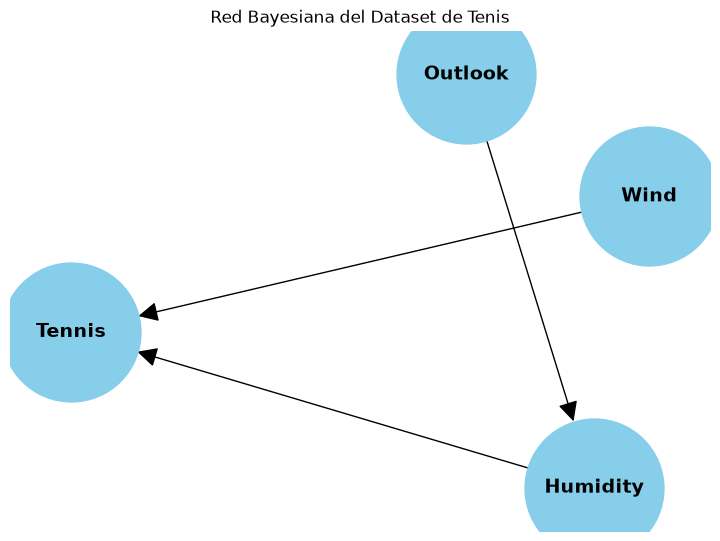

In [18]:
# Grafica de estructura
visualize_graph(model2)

In [19]:
# Aprendemos los CPDs desde los datos y verificamos que el modelo sea válido
model2.fit(data_full, estimator=DiscreteMLE())
print(model2.check_model())

for cpd in model2.get_cpds():
    print(f"\nCPD de {cpd.variable}:")
    print(cpd)

True

CPD de Outlook:
+-------------------+----------+
| Outlook(Overcast) | 0.285714 |
+-------------------+----------+
| Outlook(Rain)     | 0.357143 |
+-------------------+----------+
| Outlook(Sunny)    | 0.357143 |
+-------------------+----------+

CPD de Humidity:
+------------------+-------------------+---------------+----------------+
| Outlook          | Outlook(Overcast) | Outlook(Rain) | Outlook(Sunny) |
+------------------+-------------------+---------------+----------------+
| Humidity(High)   | 0.5               | 0.4           | 0.6            |
+------------------+-------------------+---------------+----------------+
| Humidity(Normal) | 0.5               | 0.6           | 0.4            |
+------------------+-------------------+---------------+----------------+

CPD de Tennis:
+-------------+--------------------+-----+------------------+
| Humidity    | Humidity(High)     | ... | Humidity(Normal) |
+-------------+--------------------+-----+------------------+
| Wind   

In [20]:
data_full.sort_values(by=["Humidity","Wind","Tennis"])

,Outlook,Humidity,Wind,Tennis
1,Sunny,High,Strong,No
13,Rain,High,Strong,No
11,Overcast,High,Strong,Yes
0,Sunny,High,Weak,No
7,Sunny,High,Weak,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
10,Sunny,Normal,Strong,Yes


In [21]:
# Inferencia sobre el nuevo modelo
inferencia2 = VariableElimination(model2)

print("Sin evidencia:")
print(inferencia2.query(variables=[tennis]))

print("\nEvidencia: Humidity=High")
print(inferencia2.query(variables=[tennis], evidence={humidity: 'High'}))

print("\nEvidencia: Humidity=Normal")
print(inferencia2.query(variables=[tennis], evidence={humidity: 'Normal'}))

print("\nEvidencia: Wind=Strong")
print(inferencia2.query(variables=[tennis], evidence={wind: 'Strong'}))

print("\nEvidencia: Wind=Weak")
print(inferencia2.query(variables=[tennis], evidence={wind: 'Weak'}))

print("\nEvidencia: Humidity=High, Wind=Strong")
print(inferencia2.query(variables=[tennis], evidence={humidity: 'High', wind: 'Strong'}))

print("\nEvidencia: Humidity=Normal, Wind=Weak")
print(inferencia2.query(variables=[tennis], evidence={humidity: 'Normal', wind: 'Weak'}))

Sin evidencia:
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.3571 |
+-------------+---------------+
| Tennis(Yes) |        0.6429 |
+-------------+---------------+

Evidencia: Humidity=High
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5714 |
+-------------+---------------+
| Tennis(Yes) |        0.4286 |
+-------------+---------------+

Evidencia: Humidity=Normal
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.1429 |
+-------------+---------------+
| Tennis(Yes) |        0.8571 |
+-------------+---------------+

Evidencia: Wind=Strong
+-------------+---------------+
| Tennis      |   phi(Tennis) |
+=============+===============+
| Tennis(No)  |        0.5000 |
+-------------+---------------+
| Tennis(Yes) |        0.5000 |
+-------------+---------------+

Evidencia:

In [22]:
# Como Outlook no es padre directo de Tennis, podemos preguntar por Humidity dado Outlook
print("\nEvidencia: Outlook=Sunny (efecto indirecto sobre Humidity)")
print(inferencia2.query(variables=[humidity], evidence={outlook: 'Sunny'}))


Evidencia: Outlook=Sunny (efecto indirecto sobre Humidity)
+------------------+-----------------+
| Humidity         |   phi(Humidity) |
+==================+=================+
| Humidity(High)   |          0.6000 |
+------------------+-----------------+
| Humidity(Normal) |          0.4000 |
+------------------+-----------------+


## Parte 2: Estimando distribuciones continuas.

El objetivo de esta notebook es explorar una primera manera de aproximar $p(x|y)$ y $p(y|x)$ en un dataset tabular donde $x\in\mathbb{R}^k$ y el objetivo $y$ es una variable discreta y finita $y\in\{0,\ldots,d\}⊆\mathbb{N}, d\geq 1$.

### Imports

In [23]:
import numpy as np
import seaborn as sns

from sklearn import datasets
from matplotlib import pyplot as plt

### Cargamos el dataset

In [24]:
iris = datasets.load_iris()

In [25]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [26]:
X = iris.data
y = iris.target

In [27]:
iris_df = pd.DataFrame(data=X,
             columns=iris.feature_names,
             )

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Para simplificar el problema solo trabajaremos con una variable aleatoria.

Filtramos el dataset por feature.

feature_number puede ser 0, 1, 2, 3
- 0 - sepal length (cm)
- 1 - sepal width (cm)
- 2 - petal length (cm)
- 3 - petal width (cm)

In [28]:
feature_number = 0
feature_name = iris.feature_names[feature_number]
xfeature_original = X[:,feature_number]
xfeature_original

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
       6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
       7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
       7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
       6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])

Como estamos trabajando con valores continuos, vamos a discretizarlos.

Para ello, vamos a utilizar la funcion linspace de numpy, que nos permite dividir un rango en n partes iguales. https://numpy.org/doc/stable/reference/generated/numpy.linspace.html

Hacemos el siguiente calculo para tener la cantidad de bins que deseamos ya que la librería siempre nos crea uno más.

In [29]:
NBINS = 10
bin_size = (np.max(xfeature_original) - np.min(xfeature_original)) / NBINS
end = np.max(xfeature_original) - bin_size
bins = np.linspace(start=np.min(xfeature_original), stop=end, num=NBINS)

bins

array([4.3 , 4.66, 5.02, 5.38, 5.74, 6.1 , 6.46, 6.82, 7.18, 7.54])

In [30]:
xfeature_digitized = np.digitize(x=xfeature_original, bins=bins)
xfeature_digitized

array([ 3,  2,  2,  1,  2,  4,  1,  2,  1,  2,  4,  2,  2,  1,  5,  4,  4,
        3,  4,  3,  4,  3,  1,  3,  2,  2,  2,  3,  3,  2,  2,  4,  3,  4,
        2,  2,  4,  2,  1,  3,  2,  1,  1,  2,  3,  2,  3,  1,  3,  2,  8,
        6,  8,  4,  7,  4,  6,  2,  7,  3,  2,  5,  5,  6,  4,  7,  4,  5,
        6,  4,  5,  6,  6,  6,  6,  7,  7,  7,  5,  4,  4,  4,  5,  5,  4,
        5,  7,  6,  4,  4,  4,  6,  5,  2,  4,  4,  4,  6,  3,  4,  6,  5,
        8,  6,  7, 10,  2,  9,  7,  9,  7,  6,  7,  4,  5,  6,  7, 10, 10,
        5,  8,  4, 10,  6,  7,  9,  6,  6,  6,  9,  9, 10,  6,  6,  6, 10,
        6,  6,  5,  8,  7,  8,  5,  7,  7,  7,  6,  7,  6,  5])

### Aproximamos $p(x|y)$

Para calcular la distribución $p (x | y)$ usamos *distplot kde* (Kernel Density Estimation) para cada clase con los datos originales (datos continuos y no los discretizados).

Para este paso aprovechamos que el dataset esta ordenado por clase.

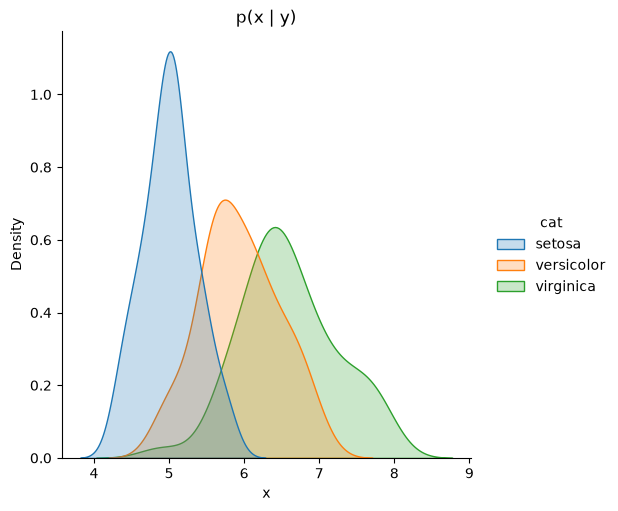

In [31]:
pd_cats = pd.DataFrame(xfeature_original.flatten(), columns=['x'])
pd_cats['cat'] = np.concatenate((np.full(50, 'setosa'),
                                np.full(50, 'versicolor'),
                                np.full(50, 'virginica')))
sns.displot(
    data=pd_cats, x='x', kind='kde',
    hue='cat', fill=True, common_norm=False
)

plt.title('p(x | y)')
plt.show()

¿Qué nos muestra esta gráfica?

El gráfico muestra la densidad estimada del "sepal lenght" para cada clase del dataset: 
    p(x|y=setosa), p(x|y=versicolor), p(x|y=virginica) 

¿Qué conclusiones puede sacar?

La "setosa" se separa claramente del resto en cuando a comportamiento, y versicolor y virginica tienen mayor solapamiento. Con el feature "sepal lenght" nos alcanza para distingir setosa del resto de las clases, pero no así en los otros casos. Por lo que sería conveniente apoyarse en otros features para distintgir mejor resto de clases.

Ejercicio: Grafique un histograma para cada clase que nos muestre $p (bin| y = clase)$ utilizando los datos discretizados. Puede utilizar la función *np.histogram*. https://numpy.org/doc/stable/reference/generated/numpy.histogram.html

Luego compare los histogramas con la gráfica de arriba sobre $p (x | y)$.

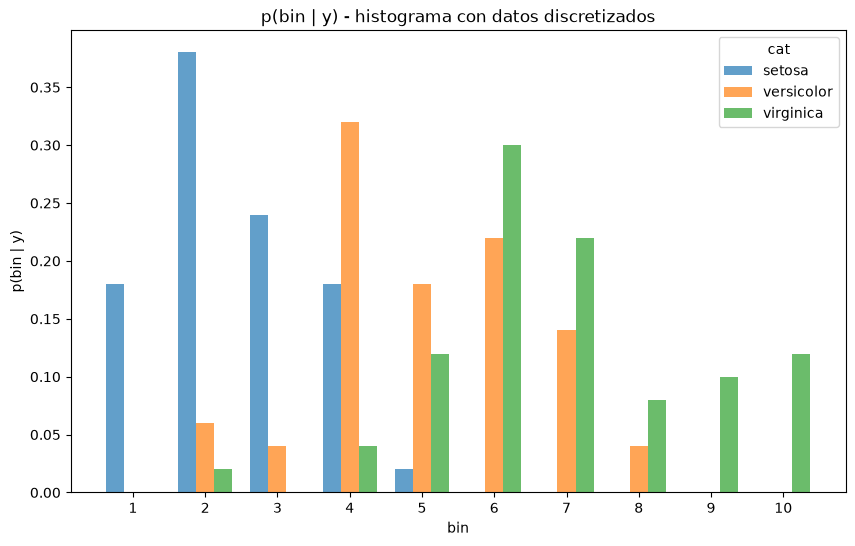

In [32]:
# p(bin | y = clase)
bin_edges = np.arange(1, NBINS + 2)  # intervalos para bins 1, ..., NBINS

# np.histogram cuenta las observaciones de cada clase que caen en cada bin.
# Al dividir por el total de observaciones de la clase obtenemos p(bin | y).
setosa_hist, _ = np.histogram(xfeature_digitized[y == 0], bins=bin_edges)
versicolor_hist, _ = np.histogram(xfeature_digitized[y == 1], bins=bin_edges)
virginica_hist, _ = np.histogram(xfeature_digitized[y == 2], bins=bin_edges)

setosa_prob = setosa_hist / setosa_hist.sum()
versicolor_prob = versicolor_hist / versicolor_hist.sum()
virginica_prob = virginica_hist / virginica_hist.sum()

bin_labels = np.arange(1, NBINS + 1)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(bin_labels - width, setosa_prob,
       width=width, label='setosa', alpha=0.7)
ax.bar(bin_labels, versicolor_prob,
       width=width, label='versicolor', alpha=0.7)
ax.bar(bin_labels + width, virginica_prob,
       width=width, label='virginica', alpha=0.7)

ax.set_xlabel('bin')
ax.set_ylabel('p(bin | y)')
ax.set_title('p(bin | y) - histograma con datos discretizados')
ax.set_xticks(bin_labels)
ax.legend(title='cat')

plt.show()

Se observa que la clase setosa se concentra en bins bajos, mientras que versicolor y virginica se solapan en los bins intermedios y altos.

### Aproximamos $p(y|x)$

Estime la probabilidad condicional de *y* dado *x* y luego muestree 10 valores de y dado que $x = 4.75$

In [33]:
from scipy.stats import gaussian_kde


In [34]:
# Seleccionamos x según su clase y
setosa_feature = xfeature_original[y == 0]
versicolor_feature = xfeature_original[y == 1]
virginica_feature = xfeature_original[y == 2]

In [35]:
# Estimamos p(x | y) con KDE para cada clase
kde_setosa = gaussian_kde(setosa_feature)
kde_versicolor = gaussian_kde(versicolor_feature)
kde_virginica = gaussian_kde(virginica_feature)

classes = iris.target_names
kdes = [kde_setosa, kde_versicolor, kde_virginica]

In [36]:
# Prior p(y), estimado a partir de las frecuencias de las clases.
# En Iris es [1/3, 1/3, 1/3] porque hay 50 ejemplos por clase.
priors = np.bincount(y) / len(y)

x_query = 4.75

In [37]:
# Verosimilitud p(x | y) evaluada en x_query
likelihoods = np.array([kde.evaluate(x_query)[0] for kde in kdes])

Calculamos:
$p(y\mid x)=\frac{p(x\mid y)\,p(y)}{p(x)}$


In [38]:
joint = likelihoods * priors
p_y_given_x = joint / joint.sum()

print("p(y | x = 4.75):")
for c, p in zip(classes, p_y_given_x):
    print(f"  p({c} | x=4.75) = {p:.4f}")

p(y | x = 4.75):
  p(setosa | x=4.75) = 0.8761
  p(versicolor | x=4.75) = 0.0960
  p(virginica | x=4.75) = 0.0278


In [39]:
# Muestreamos 10 valores de y con esa distribución.
# La semilla hace que el resultado sea reproducible.
rng = np.random.default_rng(42)
samples = rng.choice(classes, size=10, p=p_y_given_x)
print("\nMuestra de 10 valores de y dado x=4.75:")
print(samples)


Muestra de 10 valores de y dado x=4.75:
['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa']


Como en x = 4.75 es el rango en que se concentra setosa en el "sepal length", la probabilidad de setosa tiende a ser más alta que para las otras dos clases. 

### Sampleamos sobre *p(x|y)*

Realice una muestra de 50 valores de $x$ para cada valor de $y$. Recomendamos utilizar la función *gaussian_kde* de *scipy.stats*.

In [40]:
n_samples = 50
rng = np.random.default_rng(42)

# Cada KDE representa p(x | y = clase); de cada una extraemos 50 valores.
sampled_by_class = [
    kde.resample(size=n_samples, seed=rng).ravel()
    for kde in kdes
]

In [41]:
# Reunimos las muestras y su clase para poder graficarlas después.
pd_cats_sampled = pd.DataFrame({
    'x': np.concatenate(sampled_by_class),
    'cat': np.repeat(classes, n_samples)
})

Grafique $p(x|y)$ utilizando los datos sampleados y compare con la gráfica de $p(x|y)$ creada con los datos originales.

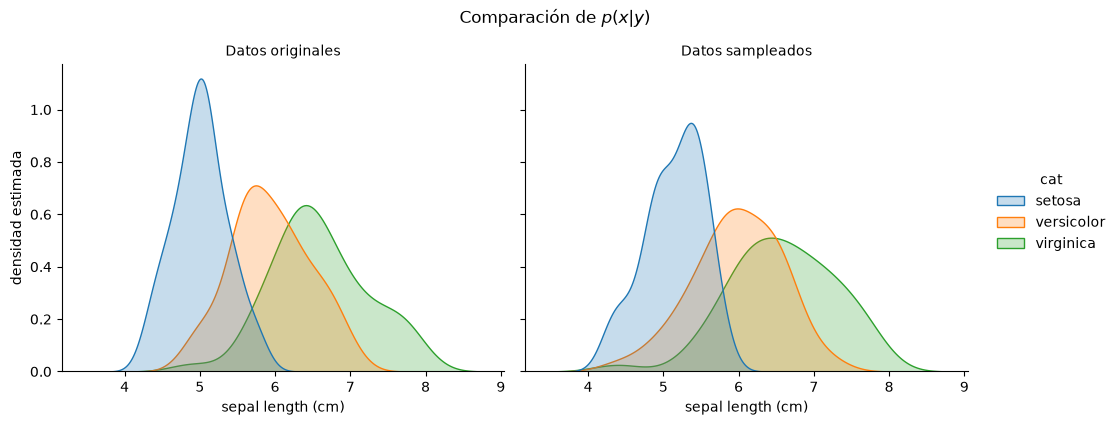

In [42]:
# Comparamos la KDE de los datos originales con la de los datos muestreados.
original_plot = pd_cats.copy()
original_plot['origen'] = 'originales'

sampled_plot = pd_cats_sampled.copy()
sampled_plot['origen'] = 'sampleados'

comparison_df = pd.concat([original_plot, sampled_plot], ignore_index=True)

g = sns.displot(
    data=comparison_df, x='x', hue='cat', col='origen',
    kind='kde', fill=True, common_norm=False,
    height=4, aspect=1.25
)
g.set_axis_labels(feature_name, 'densidad estimada')
g.set_titles('Datos {col_name}')
g.figure.suptitle('Comparación de $p(x | y)$', y=1.05)
plt.show()

Las curvas de los datos sampleados deberían conservar el patrón principal de los datos originales: setosa se concentra en valores menores de \(x\), mientras que versicolor y virginica se concentran en valores más altos y presentan solapamiento. Las curvas no son idénticas porque los datos sampleados son una realización aleatoria de las KDE estimadas. Por ello pueden cambiar levemente los picos, la dispersión y el grado de solapamiento. Además, al graficar las muestras se estima nuevamente una KDE, lo que vuelve a suavizar la distribución.

### Aproximamos la distribución normal de $p(x|y)$

In [43]:
# Separamos los datos de cada clase
setosa_feature = xfeature_original[:50]
versicolor_feature = xfeature_original[51:100]
virginica_feature = xfeature_original[101:150]

Calcule la media y la desviación estándar para cada valor de $y$.

In [44]:
setosa_mean, setosa_std = setosa_feature.mean(), setosa_feature.std()
versicolor_mean, versicolor_std = versicolor_feature.mean(), versicolor_feature.std()
virginica_mean, virginica_std = virginica_feature.mean(), virginica_feature.std()

print(f"Setosa:     media={setosa_mean:.3f}, std={setosa_std:.3f}")
print(f"Versicolor: media={versicolor_mean:.3f}, std={versicolor_std:.3f}")
print(f"Virginica:  media={virginica_mean:.3f}, std={virginica_std:.3f}")

Setosa:     media=5.006, std=0.349
Versicolor: media=5.914, std=0.493
Virginica:  media=6.594, std=0.635


Utilice la función *normal* de *np.random* para realizar una muestra sobre cada distribución normal.

In [45]:
n_samples = 50
rng = np.random.default_rng(42)

# Para cada clase, X | Y=clase ~ Normal(media_clase, std_clase).
setosa_normal_sampled = rng.normal(loc=setosa_mean, scale=setosa_std, size=n_samples)
versicolor_normal_sampled = rng.normal(loc=versicolor_mean, scale=versicolor_std, size=n_samples)
virginica_normal_sampled = rng.normal(loc=virginica_mean, scale=virginica_std, size=n_samples)

Utilizando las muestras grafique la aproximación a distribuciones normales de *p (x | y)*.

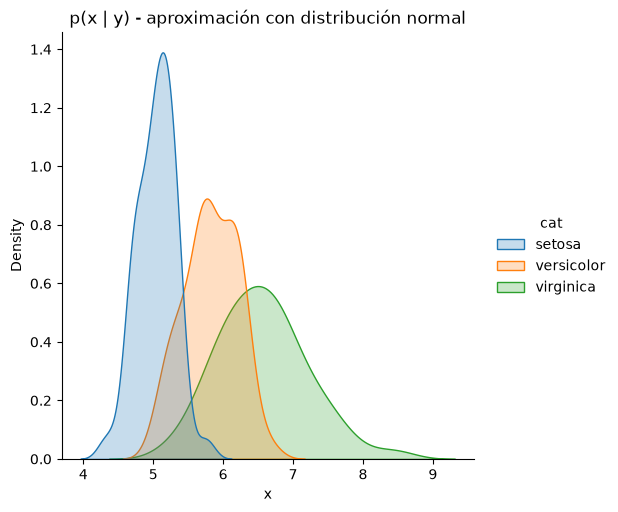

In [46]:
pd_cats_normal = pd.DataFrame(
    np.concatenate([setosa_normal_sampled, versicolor_normal_sampled, virginica_normal_sampled]),
    columns=['x']
)
pd_cats_normal['cat'] = np.concatenate((
    np.full(n_samples, 'setosa'),
    np.full(n_samples, 'versicolor'),
    np.full(n_samples, 'virginica')
))

sns.displot(
    data=pd_cats_normal, x='x', kind='kde',
    hue='cat', fill=True, common_norm=False
)
plt.title('p(x | y) - aproximación con distribución normal')
plt.show()


Compare esta gráfica con la gráfica de *p(x|y)* original.

La gráfica basada en muestras normales conserva el patrón general de la KDE original: setosa se concentra en valores menores de x y es relativamente angosta, mientras que versicolor y virginica se concentran en valores mayores y se solapan. Esto muestra que usar la media y el desvío estándar de cada clase captura razonablemente su ubicación y dispersión.

Sin embargo, esta gráfica no muestra directamente las curvas normales teóricas. Primero se generan 50 valores aleatorios de cada normal y después Seaborn estima una KDE sobre esas muestras. Por eso las curvas resultantes pueden presentar pequeñas asimetrías, picos o colas que no estaban en la normal teórica, simplemente por la variación aleatoria de una muestra finita y por el suavizado de la KDE.

La KDE original refleja la forma de los datos reales; la KDE de las muestras normales refleja una aproximación paramétrica de esos datos. La segunda suele conservar el comportamiento global, pero no necesariamente los detalles particulares de la distribución original.

### Graficamos la mezcla de Gaussianas.

Grafique la mezcla de Gaussianas.

In [47]:
from scipy.stats import norm

In [48]:
x_range = np.linspace(xfeature_original.min() - 1, xfeature_original.max() + 1, 500)

# p(y), estimado a partir de la frecuencia de cada clase.
priors = np.bincount(y) / len(y)

setosa_pdf = norm.pdf(x_range, loc=setosa_mean, scale=setosa_std)
versicolor_pdf = norm.pdf(x_range, loc=versicolor_mean, scale=versicolor_std)
virginica_pdf = norm.pdf(x_range, loc=virginica_mean, scale=virginica_std)

# p(x) = sum_y p(x | y) p(y)
mixture_pdf = (
    priors[0] * setosa_pdf
    + priors[1] * versicolor_pdf
    + priors[2] * virginica_pdf
)

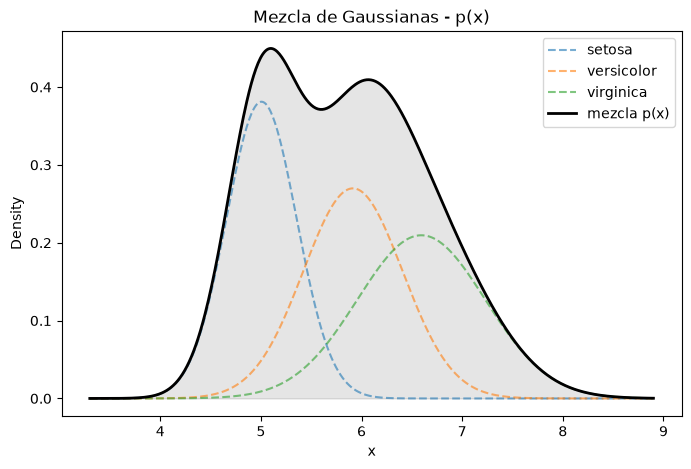

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(x_range, priors[0] * setosa_pdf, '--', label='setosa', alpha=0.6)
plt.plot(x_range, priors[1] * versicolor_pdf, '--', label='versicolor', alpha=0.6)
plt.plot(x_range, priors[2] * virginica_pdf, '--', label='virginica', alpha=0.6)
plt.plot(x_range, mixture_pdf, color='black', linewidth=2, label='mezcla p(x)')
plt.fill_between(x_range, mixture_pdf, alpha=0.1, color='black')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Mezcla de Gaussianas - p(x)')
plt.legend()
plt.show()

Compare esta gráfica con la gráfica de *p(x|y)* usando distribuciones normales.

En la gráfica anterior, cada curva representa una distribución condicional p(x | y=clase) y está normalizada de forma independiente: el área bajo cada una es 1. Por eso muestra cómo se distribuye x dentro de cada clase.

En la mezcla de Gaussianas, las curvas punteadas son p(y=clase) p(x | y=clase). Tienen la misma forma general que sus distribuciones condicionales, pero están multiplicadas por el prior de la clase. Como las tres clases de Iris tienen la misma frecuencia, cada prior es 1/3 y el área de cada curva punteada es 1/3.

La curva negra es la suma de las tres componentes: p(x) = sum_y p(x | y) p(y). Representa la distribución marginal de x cuando no conocemos la clase; en las zonas donde las clases se solapan, recibe aportes de más de una Gaussiana. A diferencia de la gráfica anterior, aquí se muestran las PDFs normales teóricas, por eso las curvas son perfectamente suaves y simétricas.

### Opcional: Aproxime $p(y|x)$ y realice una muestra de 10 valores de $y$ con $x = 4.75$

In [50]:
x_query = 4.75
classes = iris.target_names

# p(x_query | y=clase), bajo la aproximación normal de cada clase.
likelihoods = np.array([
    norm.pdf(x_query, loc=setosa_mean, scale=setosa_std),
    norm.pdf(x_query, loc=versicolor_mean, scale=versicolor_std),
    norm.pdf(x_query, loc=virginica_mean, scale=virginica_std),
])

joint = likelihoods * priors
p_y_given_x = joint / joint.sum()

In [51]:
print("p(y | x = 4.75) usando la mezcla de gaussianas:")
for c, p in zip(classes, p_y_given_x):
    print(f"  p({c} | x=4.75) = {p:.4f}")

rng = np.random.default_rng(42)
samples = rng.choice(classes, size=10, p=p_y_given_x)
print("\nMuestra de 10 valores de y dado x=4.75:")
print(samples)

p(y | x = 4.75) usando la mezcla de gaussianas:
  p(setosa | x=4.75) = 0.9368
  p(versicolor | x=4.75) = 0.0533
  p(virginica | x=4.75) = 0.0099

Muestra de 10 valores de y dado x=4.75:
['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'versicolor' 'setosa'
 'setosa' 'setosa' 'setosa']
